# Lab 5B - TD control with CliffWalking

In this lab, we study **Temporal-Difference (TD) learning** using the classic
**CliffWalking** environment from `Gymnasium`  
(https://gymnasium.farama.org/environments/toy_text/cliff_walking/).

- Before installing Gymnasium, make sure you have: Python ≥ 3.8 and pip (Python package manager)

Check this in a terminal: 

python --version
pip --version

- Installing Gymnasium (basic version)

For most reinforcement learning labs (grid worlds, CliffWalking, CartPole), run:
pip install gymnasium

- If you use conda, you can install Gymnasium with:

conda install gymnasium

Alternatively, you can use Google Colab to run this notebook without installing anything locally.

In [ ]:
from pathlib import Path

import gymnasium as gym
from gymnasium.wrappers import TimeLimit
from IPython.display import Image
from PIL import Image as PIL_Image

import matplotlib.pyplot as plt
import numpy as np


## 1. Environment Overview

CliffWalking is a toy gridworld in which an agent must move from a start state to a goal state while avoiding a dangerous cliff.
This environment is episodic, and state and action spaces are finite and discrete. 

This environment is adapted from Example 6.6 in *Sutton & Barto, Reinforcement Learning: An Introduction*.

*You can start by watching the GIF in **Section 2** to get a visual overview of this environment.*

**Grid Description**

The enviroment is a 4 × 12 grid:

- Start: bottom-left corner at position `[3, 0]`
- Goal: bottom-right corner at position `[3, 11]`
- Cliff: cells `[3, 1]` to `[3, 10]`

If the agent steps into the cliff:
- it receives a large negative reward,
- it is returned immediately to the start position,
- the episode continues.

The agent moves step-by-step until it reaches the goal.

**Action Space**

The agent has four discrete actions: 0 (move up), 1 (move right), 2 (move down), 3 (move left).

Actions that would move the agent outside the grid leave the state unchanged.

**Observation (state) space**

The observation (state) is an integer representing the agent’s current position on the grid.

Each state corresponds to one cell of the grid and is encoded as:

$$
\text{state} = \text{row} \times 12 + \text{column}
$$

For example:
- Start position `[3, 0]` corresponds to state  
  $$
  3 \times 12 + 0 = 36
  $$

The observation is returned as an `int`.

**Starting State**

Each episode begins at the **start state**:

- Location: `[3, 0]`
- State index: `36`

**Rewards**

- Every step has a reward of **−1**
- Stepping into the cliff incurs a reward of **−100**
- Reaching the goal does **not** provide a bonus reward; the final transition still yields −1 and the episode terminates.

This reward structure encourages the agent to reach the goal
in as few steps as possible while avoiding risky exploration near the cliff.

**Episode Termination**

An episode ends when:
- the agent reaches the goal at location `[3, 11]` (state `47`), or
- the episode is truncated by an external time limit (if applied)

Stepping into the cliff does **not** terminate the episode; it resets the agent to the start state.

**Transition Dynamics**

CliffWalking is **deterministic**: for any state–action pair, the next state is uniquely determined (unless `is_slippery=True`, which is disabled by default).

In [2]:
env = gym.make("CliffWalking-v1")  # create an environment object

print(type(env))

<class 'gymnasium.wrappers.common.OrderEnforcing'>


**Action space**

There are 4 possible actions and these actions are encoded as integers {0, 1, 2, 3}. 

In [3]:
print(
    env.action_space,
)  # env.action_space is an object that describes what actions are allowed;
# Discrete(4) means: the action space is finite, there are 4 possible actions and actions are encoded as integers {0, 1, 2, 3}


print(env.action_space.n)  # number of actions  # ty:ignore[unresolved-attribute]

Discrete(4)
4


We can sample a random action as follows 

In [4]:
action = env.action_space.sample()
print(action)

2


**Observation (state) space**

In [5]:
print(
    env.observation_space,
)  # There are 48 states (4 x 12 grid); Each state is represented by a single integer

print(env.observation_space.n)  # number of states  # ty:ignore[unresolved-attribute]

Discrete(48)
48


**Resetting the environment**

In [6]:
observation, info = (
    env.reset()
)  # This starts a new episode with returns: observation: the initial state (integer); info: extra diagnostics (often empty or unused)

print(observation)  # So the agent always starts at state 36.


36


**Stepping through the environment**

`env.step(action)` returns 
- `observation`: next state (int); 
- `reward`: immediate reward; 
- `terminated`: episode ended with the goal reached
- `truncated`:	episode stopped by time limit
- `info`:	extra info

In [7]:
action = env.action_space.sample()
print("the action is", action)
observation, reward, terminated, truncated, info = env.step(action)
print(observation, reward, terminated, truncated)

the action is 3
36 -1 False False


The next state run **an example of episode loop**

- observe the state,

- choose an action,

- step the environment,

- repeat until the episode ends.


In [8]:
observation, info = env.reset()  # Resets the environment to its initial state.
# In CliffWalking-v1, this means the agent is placed at the start position ( row = 3, column = 0) = state 36
print(observation)

done = False  # This variable controls the episode loop. done = False means the episode is still running
while not done:  # This loop simulates one full episode of interaction: agent chooses action, enviroment changes to new state + reward, repeat until the episode ends.
    action = (
        env.action_space.sample()
    )  # Sampling a random action : chooses one action uniformly at random
    observation, reward, terminated, truncated, info = env.step(
        action,
    )  # enviroment changes to new state + reward,
    print(
        observation,
        reward,
        terminated,
        truncated,
    )  #  Prints what happened after one transition.
    done = (
        terminated or truncated
    )  # The episode stops if either: terminated == True (task ended) or truncated == True (forced stop, where  `or` = logical “at least one”


36
24 -1 False False
25 -1 False False
36 -100 False False
24 -1 False False
12 -1 False False
12 -1 False False
0 -1 False False
1 -1 False False
2 -1 False False
3 -1 False False
3 -1 False False
15 -1 False False
14 -1 False False
15 -1 False False
16 -1 False False
4 -1 False False
5 -1 False False
4 -1 False False
16 -1 False False
17 -1 False False
5 -1 False False
4 -1 False False
3 -1 False False
4 -1 False False
16 -1 False False
15 -1 False False
16 -1 False False
15 -1 False False
14 -1 False False
13 -1 False False
1 -1 False False
0 -1 False False
12 -1 False False
24 -1 False False
36 -1 False False
36 -1 False False
36 -100 False False
36 -100 False False
36 -1 False False
36 -100 False False
36 -1 False False
24 -1 False False
12 -1 False False
12 -1 False False
0 -1 False False
0 -1 False False
0 -1 False False
1 -1 False False
1 -1 False False
0 -1 False False
0 -1 False False
0 -1 False False
12 -1 False False
24 -1 False False
25 -1 False False
36 -100 False False
3

In [ ]:
# What `or` means

print("1", True or True)  # noqa: SIM222
print("2", True or False)  # noqa: SIM222
print("3", False or True)  # noqa: SIM222
print("4", False or False)

1 True
2 True
3 True
4 False


Rewards and cliff behavior (important!)

Falling into the cliff does NOT end the episode and we come back to the starting point. 

In [10]:
env.reset()
state, reward, _, _, _ = env.step(1)  # move right into the cliff
print(state, reward)

36 -100


**Rendering the environment (text vs image)**

The following code shows the text rendering and this prints an ASCII grid. In this ASCII grid, "x" reprensente the agent

In [11]:
env = gym.make("CliffWalking-v1", render_mode="ansi")
env.reset()
print(env.render())
state, reward, _, _, _ = env.step(0)  # move up
print(env.render())
state, reward, _, _, _ = env.step(1)  # move right
print(env.render())


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  x  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T




RGB rendering (for visualization / GIFs): This is an RGB image you can display, store or convert into a GIF. See Section 2 for details. 


In [12]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")
env.reset()
frame = env.render()
print(frame.shape)

/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


(240, 720, 3)


Properly closing the environment

In [13]:
env.close()
# Always do this at the end to free resources, avoid warnings.

## 2. Visualizing an Episode of CliffWalking (GIF Rendering)

In this section, we run one episode of the *CliffWalking* environment
using a **random policy**, and we **visualize the episode as an animated GIF**.

The idea is simple:
1. Reset the environment to its starting state.
2. Let the agent interact with the environment step by step.
3. After each step, render the grid as an RGB image.
4. Store all rendered images (frames).
5. Convert the collected frames into a GIF and display it in the notebook.

This visualization is not part of the learning algorithm itself but it helps you understand the environment dynamics and see how the agent moves on the grid,

To avoid infinite episodes when using a random policy, the environment is wrapped
with a **time limit** so that the episode is automatically truncated after a fixed
number of steps.

In [14]:
def visualize(episode_render: list) -> None:
    """Convert a list of rendered frames into a GIF and display it in the notebook.

    Args:
        episode_render (list): A list of frames, where each frame is a NumPy array
        (shape: height x width x 3) representing an RGB image
        returned by env.render().

    """
    # Convert raw NumPy arrays into PIL Image objects
    # env.render() returns frames as NumPy arrays.
    # PIL (Python Imaging Library) is used to save images as a GIF.
    # We keep at most the first 100 frames to avoid creating huge GIF files.
    frames = [PIL_Image.fromarray(img) for img in episode_render[:100]]

    # Safety check: ensure we actually have frames
    # If no frames were collected, we cannot create a GIF.
    if len(frames) == 0:
        msg = "episode_render is empty (no frames to visualize)."
        raise ValueError(msg)

    # Save frames as an animated GIF
    # frames[0] is the first image of the GIF.
    # save_all=True allows multiple frames.
    # append_images=frames[1:] adds the remaining frames.
    # duration=50 means 50 milliseconds between frames, about 20 frames per second.
    # loop=0 means the GIF loops forever.
    frames[0].save(
        "CliffWalking.gif",
        save_all=True,
        append_images=frames[1:],
        duration=50,
        loop=0,
    )

    # Display the GIF inside the Jupyter notebook
    # Open the saved GIF file in binary mode
    with Path("CliffWalking.gif").open("rb") as f:
        # Read the file and display it using IPython.display.Image
        display(Image(data=f.read(), format="gif"))


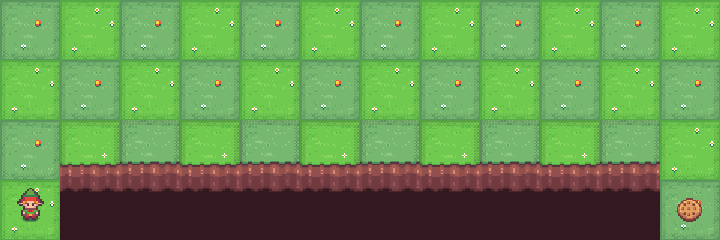

In [15]:
# Create the CliffWalking environment with a time limit

# TimeLimit ensures that the episode ends after a fixed number of steps,
# which prevents infinite loops when using a random policy.
env = TimeLimit(
    gym.make(
        "CliffWalking-v1",
        render_mode="rgb_array",  # env.render() returns an RGB image array
    ),
    max_episode_steps=100,  # maximum number of steps per episode
)

# Reset the environment to start a new episode
# observation: initial state (integer encoding the grid cell)
# info: additional diagnostic information (not used here)
observation, info = env.reset()

# Storage for rendered frames
episode_render = []

# Render and store the initial state (before any action is taken)
episode_render.append(env.render())

# Run one episode using a random policy
terminated = False  # True when the goal is reached
truncated = False  # True when the time limit is reached

# Continue stepping until the episode ends
while not (terminated or truncated):
    # Select a random action uniformly from the action space
    action = env.action_space.sample()

    # Apply the action to the environment
    observation, reward, terminated, truncated, info = env.step(action)

    # Render the current state and store the frame
    episode_render.append(env.render())

# Clean up the environment
env.close()

# Convert frames into a GIF and display it
visualize(episode_render)


## 3. SARSA control for CliffWalking 


In this section, we introduce **SARSA (State–Action–Reward–State–Action)**, an **on-policy temporal-difference control algorithm**, and apply it to the classic **CliffWalking** environment.

*Because SARSA learns the value of the **policy it actually follows** (including exploration), it tends to learn **safer paths** that stay away from the cliff when $\varepsilon$-greedy exploration is used. This contrasts with off-policy methods like Q-learning, which often learn the shorter but riskier path.*

#### SARSA: Core Idea

SARSA updates the action-value function $Q(s,a)$ using transitions of the form:

$$
(s_t, a_t, r_{t+1}, s_{t+1}, a_{t+1})
$$

The update rule is:

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t)
+ \alpha \big[ r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \big],
$$

where:
- $ \alpha $ is the learning rate,
- $ \gamma $ is the discount factor,
- $ a_{t+1} $ is selected **according to the same policy used to interact with the environment** (on-policy).


#### Policy: ε-Greedy Exploration

To balance exploration and exploitation, we use an **ε-greedy policy**:
- With probability $\varepsilon$, choose a random action (exploration).
- With probability $1 - \varepsilon$, choose the greedy action that maximizes $ Q(s,a) $.


#### What the Code Below Does

In the following implementation:

- Uses an $\varepsilon$-greedy policy to interact with the environment.
- Learns the action-value function $Q(s,a)$ using SARSA updates.


In [16]:
num_states = env.observation_space.n  # store the number of states
num_actions = env.action_space.n  # store the number of actions

print("n_states =", num_states, "n_actions =", num_actions)

# Action mapping in this env:
# 0: UP, 1: RIGHT, 2: DOWN, 3: LEFT
ACTIONS = ["↑", "→", "↓", "←"]

n_states = 48 n_actions = 4


**Exercise 1.** (Define an $\varepsilon$-Greedy Policy) 

Define an **$\varepsilon$-greedy policy**, which is a standard exploration strategy in reinforcement learning.

The goal of `epsilon_greedy` is to choose an action in state $s$ based on the current action-value function $Q(s,a)$:

- With probability **$\varepsilon$** (*exploration*): choose a **random action**
- With probability **1 − $\varepsilon$** (*exploitation*): choose the **greedy action** $a = \arg\max_a Q(s,a)$

The inputs of `epsilon_greedy` are 

-  Q : Action-value table of shape (n_states, n_actions).
-  s : Current state.
-  epsilon : Exploration probability
-  rng : Random number generator (for reproducibility).

The output `epsilon_greedy` is 

- a : the Selected action index.


In [17]:
def epsilon_greedy(
    Q: np.ndarray,
    s: int,
    epsilon: float,
    rng: np.random.Generator,
) -> int:
    """Select an action using the epsilon-greedy policy.

    Args:
        Q (np.ndarray): The action-value function, shape (num_states, num_actions)
        s (int): The current state
        epsilon (float): The probability of choosing a random action
        rng (np.random.Generator): A random number generator for reproducibility

    Returns:
        int: The selected action

    """
    if rng.random() < epsilon:
        return rng.integers(0, len(Q[s]))  # a random integers in [0, len(Q[s]))
    return int(np.argmax(Q[s]))


**Exercise 2.** (Implement SARSA Control for CliffWalking)

In this exercise, we apply SARSA algorithm to the CliffWalking environment. The goal of `train_sarsa` is to learn an action-value function $Q(s,a)$ using SARSA and an $\varepsilon$-greedy exploration. 

The inpus of `train_sarsa` are 
- env: the Gymnasium environment (CliffWalking)
- num_episodes: how many episodes of training
- alpha: learning rate alpha in (0,1],which means ``how strongly we update Q-values each step''
- gamma: discount factor gamma in (0,1]. In CliffWalking, gamma=1.0 is common because episodes are finite
- epsilon: exploration rate for epsilon-greedy policy
- seed: for reproducible randomness

The output of `train_sarsa` are 
- Q: learned action-value table Q(s,a)
- returns: total reward per episode (to evaluate the performance)
- steps_list: number of steps per episode (to evaluate the efficiency)
- cliff_falls: whether the agent fell off the cliff in that episode (to evaluate the safety)

In [ ]:
def train_sarsa(  # noqa: PLR0913
    env: gym.Env,
    num_episodes: int = 5000,
    alpha: float = 0.5,
    gamma: float = 1.0,
    epsilon: float = 0.1,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Train an agent using the SARSA algorithm.

    Args:
        env (gym.Env): The environment to train on
        num_episodes (int): Number of episodes to train
        alpha (float): Learning rate
        gamma (float): Discount factor
        epsilon (float): Exploration probability for epsilon-greedy policy
        seed (int): Random seed for reproducibility

    Returns:
        tuple: A tuple containing:
            - Q (np.ndarray): The learned action-value function
            - returns (np.ndarray): Total rewards per episode
            - steps_list (np.ndarray): Number of steps per episode
            - cliff_falls (np.ndarray): Indicator of cliff falls per episode

    """
    rng = np.random.default_rng(
        seed,
    )  # Creates a NumPy random number generator using seed.
    Q = np.zeros((num_states, num_actions))  # Creates a tabular action-value function

    returns = []  # will store the total reward G accumulated in the episode
    steps_list = []  # will store the number of steps taken before the episode ends
    cliff_falls = []  # will store 1 if the agent fell into the cliff at least once, else 0

    for _ep in range(num_episodes):  # main episode loop
        # Each iteration trains on one full episode: reset --> then step until done --> then record statistics.

        s, _info = env.reset()  # starts a new episode.
        a = epsilon_greedy(Q, s, epsilon, rng)  # select an epsilon-greedy action

        G = 0.0  # total return so far
        steps = 0  # step counter
        fell = 0  # It is a flag, fell becomes 1 if cliff penalty happens at least once

        # Initialize termination flags
        terminated = False  #  terminated = True if episode ended with goal reached
        truncated = False  #  truncated = True if episode stopped due to an external limit (e.g. timeout)

        while not (terminated or truncated):
            s2, r, terminated, truncated, _info = env.step(
                a,
            )  # Take one environment step with action a
            # s2 = next state, r = reward, terminated and truncated = episode end flags

            # Update episode statistics
            steps += 1  # increment step count
            G += r  # add reward to total return

            # Detect cliff falls
            if (
                r <= -100  # noqa: PLR2004
            ):  # In CliffWalking, falling off the cliff typically gives reward -100.
                fell = 1  # if reward is very negative (≤ -100), we mark fell = 1.
            a2 = epsilon_greedy(
                Q,
                s2,
                epsilon,
                rng,
            )  # Choose next action using the same epsilon-greedy policy

            # Compute the TD target
            # The SARSA TD target is : target = r_{t+1} + gamma * Q (s_{t+1}, a_{t+1})
            # Why Why multiply by (0 if terminated else 1)? If the episode terminated, there is no future value after terminal state.
            td_target = r + gamma * Q[s2, a2] * (0 if terminated else 1)
            Q[s, a] += alpha * (td_target - Q[s, a])  # SARSA update rule

            s, a = (
                s2,
                a2,
            )  # This shifts the time.  Next state / action becomes current state / action

        # After the while ends, the episode is over.
        returns.append(G)  # record the total return of this episode
        steps_list.append(steps)  # record the number of steps
        cliff_falls.append(fell)  # whether a cliff fall occurred

    return Q, np.array(returns), np.array(steps_list), np.array(cliff_falls)
    # final return values:
    # Q = the learned Q action value function
    # Converts the lists of returns, steps_list and cliff_falls to NumPy arrays (convenient for plotting, averaging, etc.)


Now we train SARSA with the given hyperparameters.

In [19]:
# Choosing training hyperparameters

num_episodes = 8000
alpha = 0.5
gamma = 1.0
epsilon = 0.1
seed = 42

Q_sarsa, R_sarsa, S_sarsa, F_sarsa = train_sarsa(
    env,
    num_episodes=num_episodes,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    seed=seed,
)


We now want to visualize the learning process. However, if we plot the raw episode returns and cliff-fall indicators directly, the resulting curves are often too noisy to be informative. This is due to the inherent randomness of ε-greedy exploration, which introduces large fluctuations from one episode to the next. As a result, it becomes difficult to identify overall learning trends or convergence behavior.

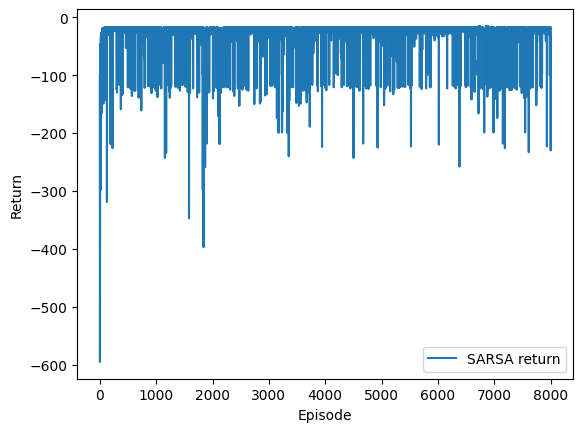

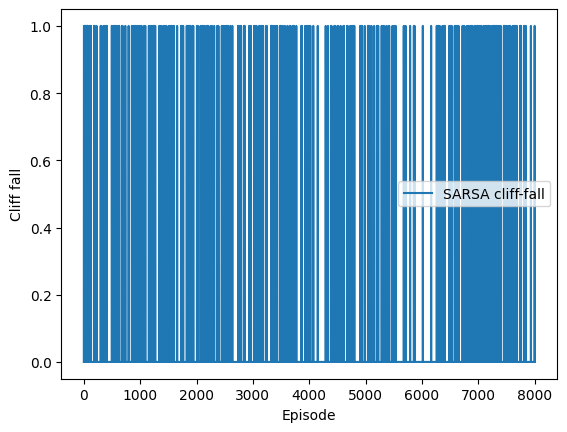

In [20]:
# bad idea :

plt.figure()
plt.plot(R_sarsa, label="SARSA return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()

plt.figure()
plt.plot(F_sarsa, label="SARSA cliff-fall")
plt.xlabel("Episode")
plt.ylabel("Cliff fall")
plt.legend()
plt.show()

To obtain a clearer picture of the learning process, it is therefore common to apply smoothing techniques such as a moving average, which reduce noise while preserving the overall trend.

**Exercise 3.** Explain what the `moving_average` function computes and why it is useful for visualizing the learning process.

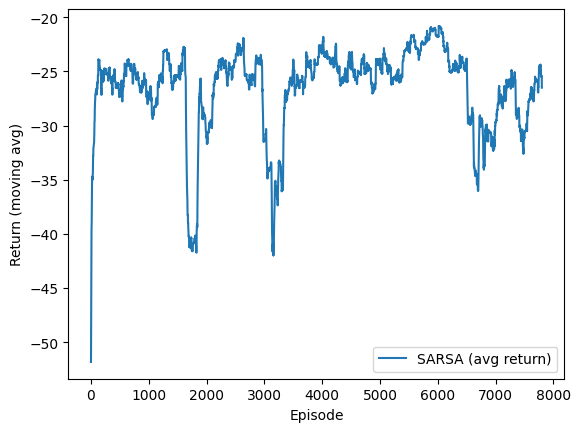

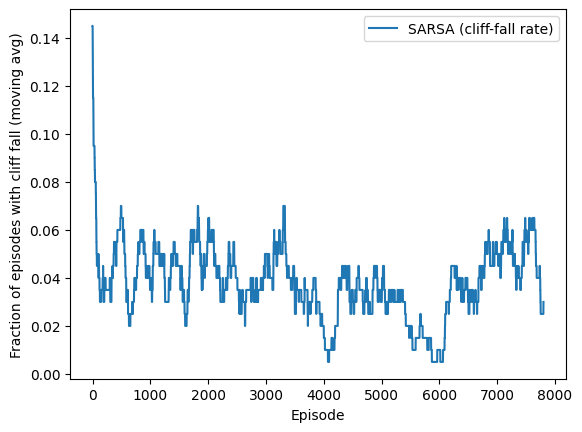

In [21]:
def moving_average(x: np.ndarray, w: int = 200) -> np.ndarray:
    """Compute the moving average of a 1D array.

    Args:
        x (np.ndarray): Input 1D array
        w (int): Window size for moving average

    Returns:
        np.ndarray: The moving average of the input array

    """
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")


plt.figure()
plt.plot(moving_average(R_sarsa, 200), label="SARSA (avg return)")
plt.xlabel("Episode")
plt.ylabel("Return (moving avg)")
plt.legend()
plt.show()

plt.figure()
plt.plot(moving_average(F_sarsa, 200), label="SARSA (cliff-fall rate)")
plt.xlabel("Episode")
plt.ylabel("Fraction of episodes with cliff fall (moving avg)")
plt.legend()
plt.show()


In [22]:
# a simple example of moving_average

test_x = np.array([1, 2, 3, 4, 5])
test_moving_average = moving_average(test_x, w=3)
print(test_moving_average)
# The first value is the average of 1,2,3 ; The second value is the average of 2,3,4; The third value is the average of 3,4,5

[2. 3. 4.]


## 4. Q-learning for CliffWalking 

In this section, we study **Q-learning** and apply it to the **CliffWalking** environment. The objective is to learn an optimal policy that allows the agent to reach the goal while avoiding the cliff, which yields a very large negative reward.

Recall that Q-learning learns also the action-value function $Q(s,a)$. During training, the agent interacts repeatedly with the environment over many episodes. At each step, actions are selected using an **ε-greedy policy**. 

**The Q-learning update rule**

After taking action $a$ in state $s$, receiving reward $r$, and transitioning to the next state $s'$, the Q-value is updated according to
$$
Q(s,a)
\;\leftarrow\;
Q(s,a)
\;+\;
\alpha \Big(
\underbrace{r + \gamma \max_{a'} Q(s',a')}_{\text{TD target}}
\;-\;
Q(s,a)
\Big).
$$

where 
- $Q(s,a)$: current estimate of the value of taking action $a$ in state $s$.
- $r$: immediate reward obtained after the action.
- $\gamma \in [0,1]$: discount factor, controlling the importance of future rewards.
- $\max_{a'} Q(s',a')$: estimated value of the *best* action in the next state $s'$.
- $\alpha \in (0,1]$: learning rate, determining how strongly new information overrides old estimates.

In episodic tasks such as CliffWalking, when the next state $s'$ is terminal, the future term $\max_{a'} Q(s',a')$ is set to zero. In this case, the update reduces to
$
Q(s,a) \leftarrow Q(s,a) + \alpha \big( r - Q(s,a) \big),
$
since there is no future reward beyond the terminal state.


**Exercise 4.** (Implement Q-learning control for CliffWalking)

In this exercise, we apply Q-learning to the CliffWalking environment. The goal of `train_q_learning` is to learn an action-value function $Q(s,a)$ using Q-learning and an $\varepsilon$-greedy exploration. 

The inpus of `train_q_learning` are 
- env: the Gymnasium environment (CliffWalking)
- num_episodes: how many episodes of training
- alpha: learning rate alpha in (0,1],which means ``how strongly we update Q-values each step''
- gamma: discount factor gamma in (0,1]. In CliffWalking, gamma=1.0 is common because episodes are finite
- epsilon: exploration rate for epsilon-greedy policy
- seed: for reproducible randomness

The output of `train_q_learning` are 
- Q: learned action-value table Q(s,a)
- returns: total reward per episode (to evaluate the performance)
- steps_list: number of steps per episode (to evaluate the efficiency)
- cliff_falls: whether the agent fell off the cliff in that episode (to evaluate the safety)

In [ ]:
def train_q_learning( # noqa: PLR0913
    env: gym.Env,
    num_episodes: int = 5000,
    alpha: float = 0.5,
    gamma: float = 1.0,
    epsilon: float = 0.1,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute the Q-learning action-value function Q(s,a) using the Q-learning update rule.

    Args:
        env (gym.Env): The environment to train on
        num_episodes (int): Number of episodes to train
        alpha (float): Learning rate
        gamma (float): Discount factor
        epsilon (float): Exploration probability for epsilon-greedy policy
        seed (int): Random seed for reproducibility

    Returns:
        tuple: A tuple containing:
            - Q (np.ndarray): The learned action-value function
            - returns (np.ndarray): Total rewards per episode
            - steps_list (np.ndarray): Number of steps per episode
            - cliff_falls (np.ndarray): Indicator of cliff falls per episode

    """
    # Compared to SARSA, the main changes are:
    # 1) TD target uses max_a' Q(s', a') (off-policy) instead of Q(s', a_next).
    # 2) Transition only store the state s not the state-action (s,a) pair.
    rng = np.random.default_rng(
        seed,
    )  # Creates a NumPy random number generator using seed.
    Q = np.zeros((num_states, num_actions))  # Creates a tabular action-value function
    returns = []  # will store the total reward G accumulated in the episode
    steps_list = []  # will store the number of steps taken before the episode ends
    cliff_falls = []  # will store 1 if the agent fell into the cliff at least once, else 0

    for _ep in range(num_episodes):  # main episode loop
        # Each iteration trains on one full episode: reset --> then step until done --> then record statistics.

        s, _info = env.reset()  # starts a new episode.
        G = 0.0  # total return so far
        steps = 0  # step counter
        fell = 0  # It is a flag, fell becomes 1 if cliff penalty happens at least once

        # Initialize termination flags
        terminated = False  #  terminated = True if episode ended with goal reached
        truncated = False  #  truncated = True if episode stopped due to an external limit (e.g. timeout)

        while not (terminated or truncated):
            a = epsilon_greedy(
                Q,
                s,
                epsilon,
                rng,
            )  # select an epsilon-greedy action
            s2, r, terminated, truncated, _info = env.step(
                a,
            )  # Take one environment step with action a
            # s2 = next state, r = reward, terminated and truncated = episode end flags

            # Update episode statistics
            steps += 1  # increment step count
            G += r  # add reward to total return

            # Detect cliff falls
            if (
                r <= -100 # noqa: PLR2004
            ):  # In CliffWalking, falling off the cliff typically gives reward -100.
                fell = 1  # if reward is very negative (≤ -100), we mark fell = 1.

            # Compute the TD target
            # The Q-learning TD target is : target = r_{t+1} + gamma * max_a' Q (s_{t+1}, a')
            # Why Why multiply by (0 if terminated else 1)? If the episode terminated, there is no future value after terminal state.
            td_target = r + gamma * np.max(Q[s2]) * (0 if terminated else 1)
            Q[s, a] += alpha * (td_target - Q[s, a])  # Q-learning update rule

            s = s2  # This shifts the time.  Next state becomes current state

        # After the while ends, the episode is over.
        returns.append(G)  # record the total return of this episode
        steps_list.append(steps)  # record the number of steps
        cliff_falls.append(fell)  # whether a cliff fall

    return Q, np.array(returns), np.array(steps_list), np.array(cliff_falls)

Now we compare the learning processes of SARSA and Q-learning. What do you observe?

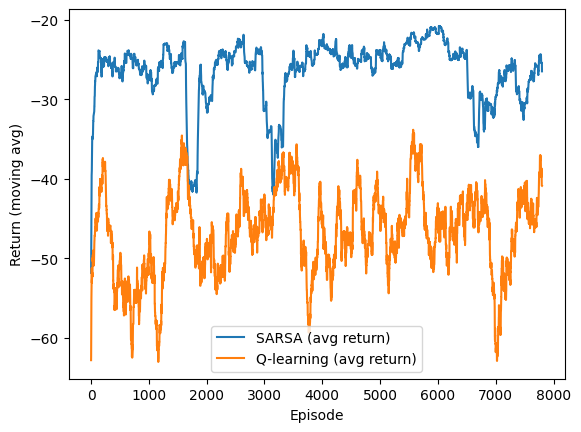

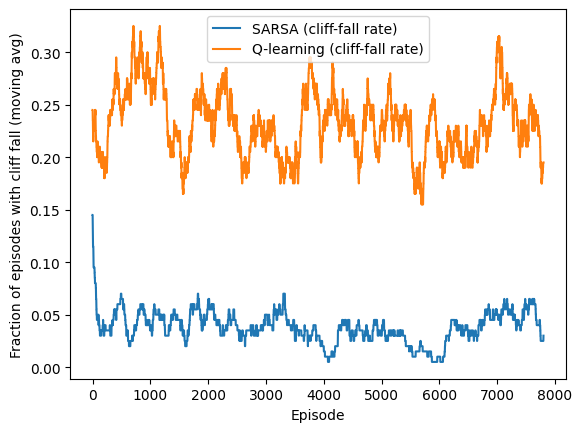

In [24]:
num_episodes = 8000
alpha = 0.5
gamma = 1.0
epsilon = 0.1
seed = 42

Q_sarsa, R_sarsa, S_sarsa, F_sarsa = train_sarsa(
    env,
    num_episodes=num_episodes,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    seed=seed,
)
Q_ql, R_ql, S_ql, F_ql = train_q_learning(
    env,
    num_episodes=num_episodes,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    seed=seed,
)

plt.figure()
plt.plot(moving_average(R_sarsa, 200), label="SARSA (avg return)")
plt.plot(moving_average(R_ql, 200), label="Q-learning (avg return)")
plt.xlabel("Episode")
plt.ylabel("Return (moving avg)")
plt.legend()
plt.show()

plt.figure()
plt.plot(moving_average(F_sarsa, 200), label="SARSA (cliff-fall rate)")
plt.plot(moving_average(F_ql, 200), label="Q-learning (cliff-fall rate)")
plt.xlabel("Episode")
plt.ylabel("Fraction of episodes with cliff fall (moving avg)")
plt.legend()
plt.show()


In the following cell, the function `s_to_rc` converts the state number into (row, col), where divmod(a, b) returns a pair:

- a // b (integer quotient)

- a % b (remainder)

Here it is exactly 

- row = s // n_cols

- col = s % n_cols.

The function `rc_to_s` converts (row, col) back into the number of state s.

In [25]:
n_rows, n_cols = 4, 12


def s_to_rc(s: int) -> tuple[int, int]:
    """Convert a state index to (row, column) coordinates."""
    return divmod(s, n_cols)  # (row, col)


def rc_to_s(r: int, c: int) -> int:
    """Convert (row, column) coordinates to a state index."""
    return r * n_cols + c


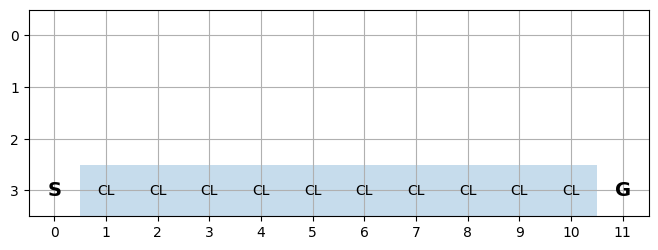

In [ ]:
start_rc = (n_rows - 1, 0)  # the start point is [3,0], which is the bottom-left point.
goal_rc = (
    n_rows - 1,
    n_cols - 1,
)  # The goal point is goal_rc = (3, 11), which is the bottom-right point.

cliff_cells = [
    (n_rows - 1, c) for c in range(1, n_cols - 1)
]  # Cliff_cells are bottom row, middle columns [(3,1), (3,2), ..., (3,10)]


# The function draw_grid_background takes a Matplotlib Axes object ax
# (like what you get from fig, ax = plt.subplots())
# and draws the grid + cliff + labels on it.


def draw_grid_background(ax: plt.Axes) -> None:
    """Draw the CliffWalking grid, cliff, start and goal on the given Axes."""
    # base grid
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.grid(True)  # noqa: FBT003
    ax.set_aspect("equal")

    # mark cliff
    for r, c in cliff_cells:
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, alpha=0.25))
        ax.text(c, r, "CL", ha="center", va="center")

    # start, goal
    ax.text(
        start_rc[1],
        start_rc[0],
        "S",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
    )
    ax.text(
        goal_rc[1],
        goal_rc[0],
        "G",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
    )


# test draw_grid_background function

fig, ax = plt.subplots(figsize=(8, 3))
draw_grid_background(ax)
plt.show()

In the following cell, we define three functions that **extract a policy and value function from a Q-table** and **visualize them on the CliffWalking grid**.

Recall that 
- `Q` is a NumPy array of shape `(nS, nA)`
- `Q[s, a]` is the action-value function of taking action `a` in state `s`

In the following, 

`greedy_policy_from_Q(Q)` constructs a deterministic greedy policy from a Q-table.

`V_from_Q(Q)` computes the state-value function induced by the greedy policy from the Q function 

and 

`plot_policy_and_values(Q, title="")` visualizes the state-value function V(s) as numbers in each grid cell, the greedy policy as arrows in each grid cell, on top of the CliffWalking grid.

In [27]:
def greedy_policy_from_Q(Q: np.ndarray) -> np.ndarray:
    """Derive the greedy policy from the action-value function Q."""
    return np.argmax(Q, axis=1)


def V_from_Q(Q: np.ndarray) -> np.ndarray:
    """Compute the state-value function V from the action-value function Q."""
    return np.max(Q, axis=1)


def plot_policy_and_values(Q: np.ndarray, title: str = "") -> None:
    """Plot the policy and state values derived from the action-value function Q."""
    pi = greedy_policy_from_Q(Q)
    V = V_from_Q(Q)

    _fig, ax = plt.subplots(figsize=(12, 4))
    draw_grid_background(ax)

    # show values as text
    for s in range(num_states):
        r, c = s_to_rc(s)
        if (r, c) in cliff_cells:
            continue
        ax.text(c + 0.32, r + 0.32, f"{V[s]:.0f}", fontsize=8, ha="right", va="bottom")

    # show arrows
    for s in range(num_states):
        r, c = s_to_rc(s)
        if (r, c) in cliff_cells:
            continue
        if (r, c) == start_rc or (r, c) == goal_rc:
            continue
        a = pi[s]
        ax.text(c, r, ACTIONS[a], ha="center", va="center", fontsize=12)

    ax.set_title(title)
    plt.show()


We now visualize, for both SARSA and Q-learning, the learned greedy policy and the corresponding state-value function, displayed on the CliffWalking grid.

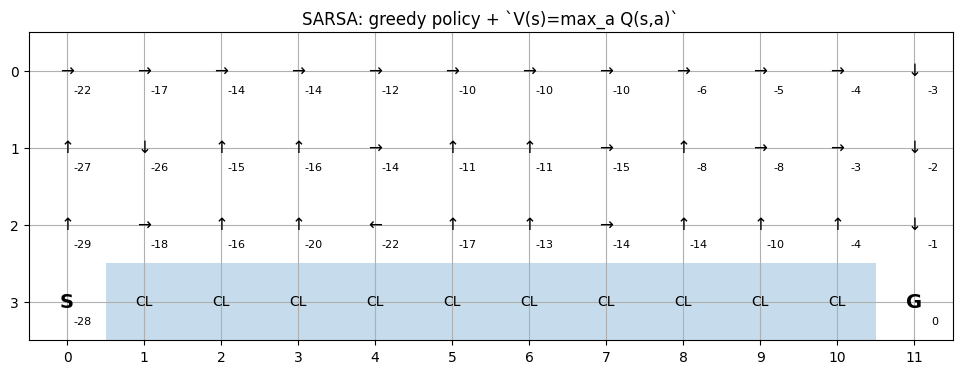

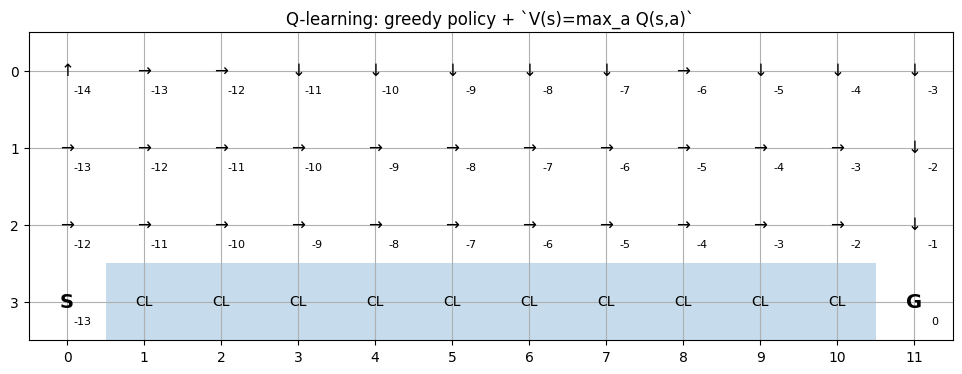

In [28]:
plot_policy_and_values(Q_sarsa, "SARSA: greedy policy + `V(s)=max_a Q(s,a)`")
plot_policy_and_values(Q_ql, "Q-learning: greedy policy + `V(s)=max_a Q(s,a)`")

We now visualize the optimal policies learned by SARSA and Q-learning. For each algorithm, we extract the greedy policy from the learned Q-table, place the agent at the start state, and let it follow this policy to generate a trajectory.


To do this, let us define two functions:

1. `rollout_policy`: executes a given policy in the environment and records the trajectory.
2. `plot_trajectory`: visualizes the resulting trajectory on the CliffWalking grid.


In [ ]:
def rollout_policy(
    env: gym.Env,
    pi: np.ndarray,
    max_steps: int = 200,
    seed: int = 0,
) -> tuple[list[int], list[float], bool, bool]:
    """Rollout a policy pi in the environment env for at most max_steps.

    Args:
        env (gym.Env): The environment to rollout the policy in
        pi (np.ndarray): The policy to rollout, shape (num_states,)
        max_steps (int): Maximum number of steps to rollout
        seed (int): Random seed for reproducibility

    Returns:
        tuple: A tuple containing:
            - states (list[int]): List of visited states
            - rewards (list[float]): List of received rewards
            - terminated (bool): Whether the episode terminated normally
            - truncated (bool): Whether the episode was truncated due to max_steps

    """
    _rng = np.random.default_rng(seed)
    s, _info = env.reset()

    states = [s]
    rewards = []

    terminated = False
    truncated = False

    for _t in range(max_steps):
        a = int(pi[s])
        s2, r, terminated, truncated, _info = env.step(a)
        states.append(s2)
        rewards.append(r)
        s = s2
        if terminated or truncated:
            break

    return states, rewards, terminated, truncated


def plot_trajectory(states: list[int], title: str = "Trajectory") -> None:
    """Plot the trajectory of states on the CliffWalking grid."""
    _fig, ax = plt.subplots(figsize=(12, 4))
    draw_grid_background(ax)

    # convert to (r,c)
    path = [s_to_rc(s) for s in states]
    xs = [c for (r, c) in path]
    ys = [r for (r, c) in path]

    ax.plot(xs, ys, marker="o")
    ax.set_title(title)
    plt.show()


We now compare the greedy policies learned by SARSA and Q-learning by simulating one episode from the start state and visualizing the resulting trajectories on the CliffWalking grid. What do you observe?

In particular, notice that:

- SARSA typically learns a safer policy, keeping the agent farther away from the cliff to reduce the risk of falling.

- Q-learning often learns a more aggressive policy, moving closer to the cliff in order to minimize the number of steps to the goal.

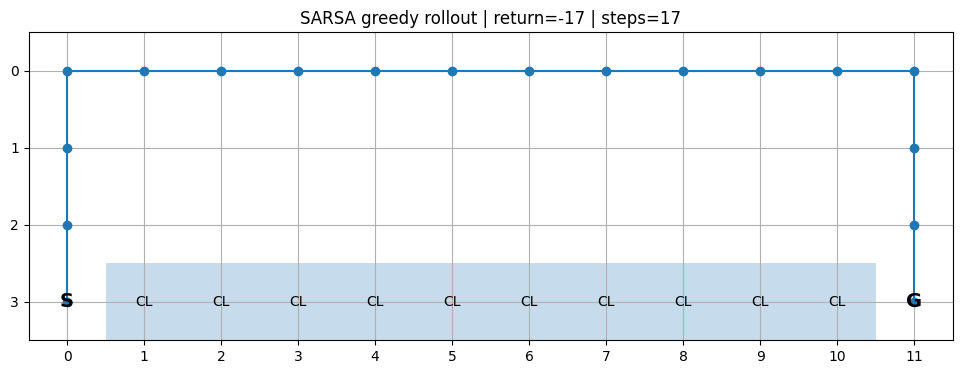

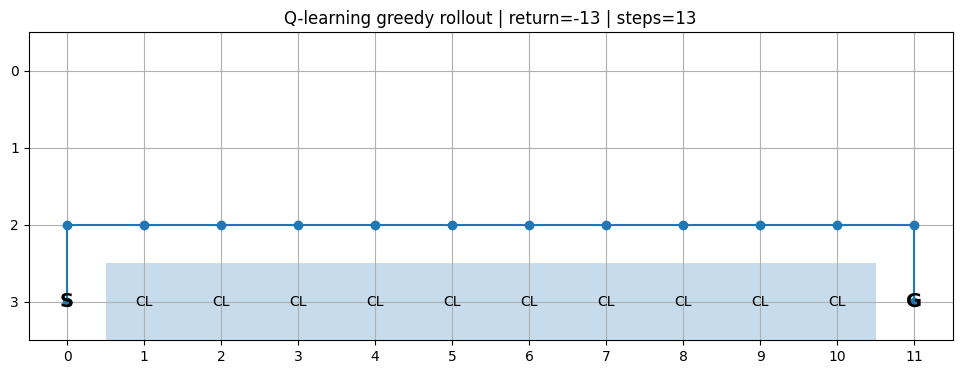

In [ ]:
pi_sarsa = greedy_policy_from_Q(Q_sarsa)
pi_ql = greedy_policy_from_Q(Q_ql)

states, rewards, term, trunc = rollout_policy(env, pi_sarsa, seed=123)
plot_trajectory(
    states,
    title=f"SARSA greedy rollout | return={sum(rewards)} | steps={len(rewards)}",
)

states, rewards, term, trunc = rollout_policy(env, pi_ql, seed=123)
plot_trajectory(
    states,
    title=f"Q-learning greedy rollout | return={sum(rewards)} | steps={len(rewards)}",
)


## Advanced Questions

**Question 1.**  

Explain why SARSA typically learns a safer policy than Q-learning in the CliffWalking environment.  
Relate your answer to the on-policy versus off-policy nature of the two algorithms.


**Question 2.**  

Study how varying $\varepsilon$ in $\varepsilon$-greedy exploration affects the learned policies of SARSA and Q-learning.  
Which algorithm is more sensitive to $\varepsilon$, and why?


**Question 3.**  

Plot the cumulative reward per episode for SARSA and Q-learning.  
Explain the differences in terms of:
- convergence speed,
- variance during training.

**Question 4.**  

Compare the policies learned by SARSA and Q-learning:
- after a small number of episodes,
- after convergence.

Which algorithm is more robust during the early stages of training?

**Question 5.**  

Implement Expected SARSA and compare it with SARSA and Q-learning on the CliffWalking environment.  
Where does it lie in terms of safety and performance?

**Question 6.**  

Replace $\varepsilon$-greedy exploration with a softmax (Boltzmann) policy.  
How does this change the learned behavior near the cliff?
